### Source of this Notebook: https://gpaw.readthedocs.io/summerschools/summerschool24/intro/intro.html


# Introduction to Python and ASE and some useful libraries

Python is a programming language that has become a de-facto standard within scientific programming.  It is also very popular for teaching programming and computer science. One of the advantages of the language is that it is relatively easy to read and understand pre-existing code.

### Python Notebooks

We are working with Python notebooks.  A notebook is split into cells (this is a text cell, most cells contain a block of Python code).  You can execute a cell by pressing Shift+Enter.  You can edit a text cell by doubleclicking it.  You can change the type of a cell on the menu bar above, use "Markup" for text and "Code" for Python code.  There are also buttons for adding and removing cells.  Cells can be split into two (or merged) on the Edit menu.



## Importing the necesary modules

A lot of helper packages for e.g. numeric calculations, plotting, atomic-scale simulations etc are available in Python, but you need to "import" the module to get access to it (you also often need to install it, but that has been taken care of here).

A few packages support special integration with Notebooks, this includes the plotting package ``matplotlib``, where the integration is enabled with a notebook-specific command starting with the ``%`` character.

You can add comments to Python code by using the ``#`` character.

Some links for reference:
* [Python](https://www.python.org/)
* Numerical package [NumPy](https://www.numpy.org/)
* Scientific package [Scipy](https://www.scipy.org/)
* Plotting package [Matplotlib](https://matplotlib.org/)


In [ ]:
%matplotlib notebook
import matplotlib.pyplot as plt    # For nice plotting
import numpy as np                 # Mathematical operations


Let's try some simple stuff.


In [ ]:
2 + 3

In [ ]:
print('Hello')

In [ ]:
print('Hello ' * 5)

In [ ]:
[1,3,5,6,7]*5

In [ ]:
np.array([1,3,5,6,7])*5

In [ ]:
# help is useful for getting help of af method
help(print)

# you can also use a question mark to get help in a Jupyter notebook,
# this opens up a new window (close it if you like)
?print


## Variables and data types

In python, variables contain data of different types, such as numbers or text strings.  You can print a variable with the ``print()`` function:


In [ ]:
a = 42
mypi = 3.14
b = "some text"
print(a)
print("Pi is approximately", mypi)
print(b)


The usual mathematical operations are possible.  The operator for exponentiation is the double star.


In [ ]:
print(2 * a)
print(16**2)
print(a + 2 * mypi)


### A `list` is an ordered collection of arbitrary objects

You will need lists of data. A list of data can be specified at once, or built gradually. The latter is demonstated later.


In [ ]:
primes = [2, 3, 5, 7, 11, 13, 17, 19, 23]
print(primes)


Lists are indexed starting with 0, so primes[1] is the *second* prime.  You can also access a list from the end, using negative numbers.


In [ ]:
print(primes[0])
print(primes[-2])


A `list` can contain arbitrary objects


In [ ]:
# a list
l = [1, ('gg', 7), 'hmm', 1.2]
print(l)
print(l[1])   # Python counts from zero, so this is the second element
print(l[-2])  # indexing with negative numbers counts from the end

In [ ]:
('gg', 7).type


### A `dict`  is a mapping from keys to values


In [ ]:
d = {'s': 0, 'p': 1}
print(d)
print(d['p'])
print('Removing an element from the dictionary')
del d['s']
print(d)


### A `tuple`  is an ordered collection like a list but is *immutable*
useful for keywords in `dict`


In [ ]:
# with a list we can reassign values
x = [2, 3]
x[0] = 100
print(x)
# this it not possible with a tuple
y = (2, 3)
print('y = ', y)
try:
    y[0] = 100
except Exception as x:
    print(x)
print('y = ', y)


### A ``namedtuple`` is a tuple where the elements also have names.

They can be accessed by index or by name.


In [ ]:
from collections import namedtuple
SKN = namedtuple('IndexSKN', ('spin', 'kpt', 'band'))
a = SKN(0, 3, 4)
print(a)
# The elements may be accessed by index (like a normal tuple) or by name:
print(a[1])
print(a.kpt)

In [ ]:
# lets try and use a namedtuple as keys for a dict
d = {}
d[SKN(0, 10, 5)] = 3.14
d[SKN(0, 1, 3)] = 2.72
print(d)

In [ ]:
key = SKN(spin=0, kpt=1, band=3)
print(d[key])
print(d[(0, 1, 3)])  # one can also use a normal tuple as key


# NumPy
#### NumPy arrays are heavely used in [ASE](https://wiki.fysik.dtu.dk/ase/)
ASE makes heavy use of an extension to Python called NumPy. The NumPy module
defines an `ndarray` type that can hold large arrays of uniform
multidimensional numeric data. An array is similar to a `list` or a `tuple`,
but it is a lot more powerful and efficient.


In [ ]:
import numpy as np
x = np.array([1, 2, 3])
print(x)
print(x.mean())

In [ ]:
# Multidimensional array
# a = np.zeros((5,10))
# a = np.ones((5,10))
a = np.identity(5)
a[:, 1] = 1.0
a[1, :] = 2.0
print("The shape of the array:", a.shape)
print("Number of dimensions:", a.ndim)
print("Data type:", a.dtype)
print("And one can print the entire array (if it is not too big):")
print(a)

In [ ]:
# Matrix muliplication
print('shape of a', a.shape)
print('shape of a.T', a.T.shape)  # .T transpose a matrix
b = np.dot(a, a.T)
print(b)
# in a more READABLE way one can use @ to dot matrices together
c = a @ a.T
print('is c equal to b:', (c == b).all())

In [ ]:
# Elementwise multiplication
d = a * a
print(d)

In [ ]:
seed = 12345678
rng = np.random.default_rng(seed)
rand = rng.random
rand((2, 2))

In [ ]:
# Random Hermitian matrix
seed = 12345678
rng = np.random.default_rng(seed)
rand = rng.random
H = rand((6, 6)) + 1j * rand((6, 6))  # 1j = sqrt(-1)
H = H + H.T.conj()

# Eigenvalues and eigenvectors
eps, U = np.linalg.eig(H)

#  Make print of numpy arrays less messy:
np.set_printoptions(precision=3, suppress=True)
print('The eigenvalues are:', eps.real)

# lets try and sort them
sorted_indices = eps.real.argsort()
eps = eps[sorted_indices]
U = U[:, sorted_indices]
print('after sorting: ', eps.real)

# Check that U diagonalizes H
D1 = np.diag(eps)  # Diagonal matrix
D2 = U.T.conj() @ H @ U  # Diagonalized H matrix
print('Diagonal matrix (from eigenvalues):')
print(D1)
print('Diagonal matrix (tranforming H):')
print(D2)
print('Are the numbers in the two matrices close to each other?')
print(np.allclose(D2, D1))



# Plotting with matplotlib
 see here for more details [Matplotlib](https://matplotlib.org/)


In [ ]:
# In a Jupyter Notebook, this magic line gives nice inline figures,
# with interactive possibilities.
# This line MUST appear before you import matplotlib or a package
# using matplotlib (e.g. ase)
# %matplotlib notebook
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# Some data
x = [1.4, 2.0, 3.0, 3.3]
y = [10, -1.1, 2.2, 5.0]
y2 = [1, 2, 3, 5]

In [ ]:
plt.figure()   # Start a new figure
# Plot y versus x (called "Series 1" in the legend).
#   b = blue.  o = show points.  - = show line.
plt.plot(x, y, 'bo-', label="Series 1")
# Plot y2 versus x (called "Series 2" in the legend).
#   r = red.  x = show points as x'es.   -- = show dashed line
plt.plot(x, y2, 'rx--', label="Series 2")
plt.title("Title of the plot")
plt.xlabel("Label of the x-axis")
plt.ylabel("Label of the y-axis")
# plt.ylim(0, 10)     # Uncomment to set range of y values to show - similar for x.
plt.legend()  # Make a legend, let matplotlib decide where to place it.
plt.show()


You can save the plot as a figure by pressing the "floppy disk" icon.  Note that in some browsers it does not work, then you can stop the interactive plot by clicking the blue on/off button in the upper right corner, and then save the plot as any other figure in your browser (probably by left-clicking it).

Sometimes, you need larger fonts in a plot that you want to include in a report.  Below is the same plot, but with larger fonts.  We also overrule the placement of the legend.


In [ ]:
plt.figure()
plt.plot(x, y, 'bo-', label="Series 1")
plt.plot(x, y2, 'rx--', label="Series 2")
plt.title("Title of the plot", size=24)
plt.xlabel("Label of the x-axis", size=16)
plt.ylabel("Label of the y-axis", size=16)
# Make tick marks larger, and increase the font.
plt.tick_params(axis='both', which='major', labelsize=16, size=10)
plt.ylim(-0.2, 10.2)     # Set range of y values to show - similar for x.
plt.legend(loc="upper left", fontsize=16)  # Make a legend, specify location.
plt.tight_layout()   # Fixes that otherwise some of the labels are cropped.
plt.show()


More advanced example with multiple sub-plots.


In [ ]:
fig, axs = plt.subplots(1, 2, sharey=True)
x = np.linspace(0, 2 * np.pi, 100)
axs[0].plot(x, np.cos(x), label='cos')
axs[1].plot(x, np.sin(x), label='sin')
axs[0].legend()
axs[1].legend()
plt.show()


Plotting a countour


In [ ]:
x = np.linspace(-1, 1, 100)
y = np.linspace(-2, 2, 100)
X, Y = np.meshgrid(x, y)
Z = X**2 + Y**2
N = 15

fig, ax = plt.subplots(1, 1)
ax.contour(X, Y, Z, N)
ax.set_aspect('equal')


# ASE (atomic simulation environment)
More details can be found here: https://wiki.fysik.dtu.dk/ase/index.html



## Everything starts with a structure!
In ASE the most important ingredients is the `Atom` and `Atoms`
objects used to setup an atomic structure.
### Setting op a molecule using the `Atoms` object


In [1]:
from ase import Atoms
d = 1.1
co = Atoms('CO', positions=[[0, 0, 0], [0, 0, d]])

In [2]:
# lets try and visualize it using the build in viewer in ase
from ase.visualize import view
view(co)

<Popen: returncode: None args: ['/home/sheren/anaconda3/envs/mylecture/bin/p...>


### Setting up a periodic structure


In [3]:
d = 2.9
L = 10
wire = Atoms('Au', positions=[[0, L / 2, L / 2]],
             cell=[d, L, L], pbc=[1, 0, 0])
# lets try and repeat it and visualize primitive and repeated
wire10 = wire * (10, 1, 1)
view([wire, wire10])

<Popen: returncode: None args: ['/home/sheren/anaconda3/envs/mylecture/bin/p...>


## Nitrogen on copper
### Exercise of the relaxation of a molecule on a surface
This section gives a quick (and incomplete) overview of what ASE can do.

We will calculate the adsorption energy of a nitrogen molecule on a copper
surface. This is done by calculating the total energy for the isolated slab
and for the isolated molecule. The adsorbate is then added to the slab and
relaxed, and the total energy for this composite system is calculated. The
adsorption energy is obtained as the sum of the isolated energies minus the
energy of the composite system.

You can read more about the optimizers in ASE here:
https://wiki.fysik.dtu.dk/ase/ase/optimize.html

#### 1. Try to go through the script so you understand what is going on
#### 2. Calculate the adsorption energy of N2 on a 4x4x2 fcc111 slab (result= 0.324 eV)
#### 3. Try a couple of different optimizers and see which one is the fastest


In [4]:
from ase import Atoms
from ase.calculators.emt import EMT
from ase.constraints import FixAtoms
from ase.optimize import QuasiNewton, BFGS, FIRE
from ase.build import fcc111, add_adsorbate
from ase.visualize import view

h = 2.85
d = 1.10

# Set up a slab:
slab = fcc111('Cu', size=(4, 4, 2), vacuum=10.0)

slab.calc = EMT()
e_slab = slab.get_potential_energy()
# setup a molecule
molecule = Atoms('2N', positions=[(0., 0., 0.), (0., 0., d)])
molecule.calc = EMT()
e_N2 = molecule.get_potential_energy()

add_adsorbate(slab, molecule, h, 'ontop')
constraint = FixAtoms(mask=[a.symbol != 'N' for a in slab])
slab.set_constraint(constraint)
dyn = QuasiNewton(slab, trajectory='N2Cu.traj')
dyn.run(fmax=0.025)

print('Adsorption energy:', e_slab + e_N2 - slab.get_potential_energy())

                Step[ FC]     Time          Energy          fmax
BFGSLineSearch:    0[  0] 10:40:23       11.886206       3.0183
BFGSLineSearch:    1[  2] 10:40:23       11.736409       0.4835
BFGSLineSearch:    2[  3] 10:40:23       11.733539       0.1447
BFGSLineSearch:    3[  5] 10:40:23       11.732679       0.1964
BFGSLineSearch:    4[ 11] 10:40:23       11.632045       0.4522
BFGSLineSearch:    5[ 13] 10:40:23       11.630093       0.5012
BFGSLineSearch:    6[ 15] 10:40:23       11.625438       0.0750
BFGSLineSearch:    7[ 16] 10:40:23       11.625242       0.0218
Adsorption energy: 0.3241577666887405


In [ ]:
# Visualize the trajectory
!ase gui N2Cu.traj

In [5]:
from ase.io import read

# Load the trajectory file
atoms_list = read('N2Cu.traj', index=':')  # `:` loads all steps as a list of Atoms objects

# Access properties for each frame
for atoms in atoms_list:
    print("Positions:", atoms.get_positions())
    print("Energy:", atoms.get_potential_energy())
    print("Forces:", atoms.get_forces())

Positions: [[-4.72336148e-17  1.47377633e+00  1.00000000e+01]
 [ 2.55265548e+00  1.47377633e+00  1.00000000e+01]
 [ 5.10531096e+00  1.47377633e+00  1.00000000e+01]
 [ 7.65796644e+00  1.47377633e+00  1.00000000e+01]
 [ 1.27632774e+00  3.68444082e+00  1.00000000e+01]
 [ 3.82898322e+00  3.68444082e+00  1.00000000e+01]
 [ 6.38163870e+00  3.68444082e+00  1.00000000e+01]
 [ 8.93429418e+00  3.68444082e+00  1.00000000e+01]
 [ 2.55265548e+00  5.89510531e+00  1.00000000e+01]
 [ 5.10531096e+00  5.89510531e+00  1.00000000e+01]
 [ 7.65796644e+00  5.89510531e+00  1.00000000e+01]
 [ 1.02106219e+01  5.89510531e+00  1.00000000e+01]
 [ 3.82898322e+00  8.10576981e+00  1.00000000e+01]
 [ 6.38163870e+00  8.10576981e+00  1.00000000e+01]
 [ 8.93429418e+00  8.10576981e+00  1.00000000e+01]
 [ 1.14869497e+01  8.10576981e+00  1.00000000e+01]
 [ 0.00000000e+00  0.00000000e+00  1.20842345e+01]
 [ 2.55265548e+00  0.00000000e+00  1.20842345e+01]
 [ 5.10531096e+00  0.00000000e+00  1.20842345e+01]
 [ 7.65796644e+00  0

In [6]:
from ase.io import read, write

# Convert the trajectory file to XYZ format
atoms = read('N2Cu.traj', index=':')  # read all frames
write('N2Cu.xyz', atoms)

/home/sheren/anaconda3/envs/mylecture/lib/python3.12/site-packages/ase/io/extxyz.py:311: UserWarning: Skipping unhashable information adsorbate_info
  warnings.warn('Skipping unhashable information '


In [14]:
plot_atoms?

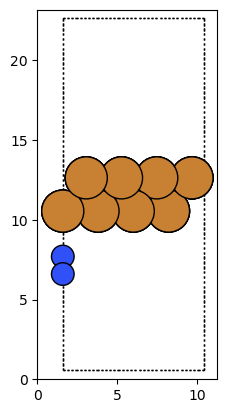

In [18]:
import matplotlib.pyplot as plt
from ase.io import read
from ase.visualize.plot import plot_atoms

atoms_list = read('N2Cu.traj', index=':')

fig, ax = plt.subplots()
for atoms in atoms_list:
    ax.clear()
    plot_atoms(atoms, ax=ax, rotation='90x,90y,0z', show_unit_cell=2)
    plt.pause(1)  # Adjust pause time for animation speed
plt.show()


## Band structure
#### Using ASE to setup band structures for Al using a Freelectron model and DFT
#### 1. What is the crystal structure of Al?
#### 2. Try and look up the recommeded Brillouin zone path for crystal structure [here](https://wiki.fysik.dtu.dk/ase/ase/dft/kpoints.html)
#### 3. Can you figure out what the `nbands=-10` and `convergence={'bands': -5}` parameters means in the GPAW DFT input below ? (Hint try and look at the output file `Al.txt`)


<Axes: ylabel='energies [eV]'>

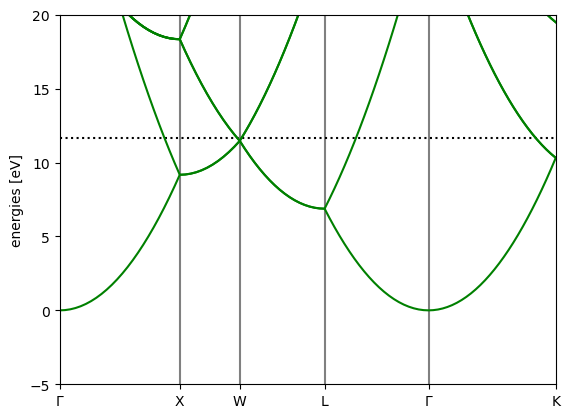

In [25]:
# simple free electron calculator
from ase.build import bulk
from ase.calculators.test import FreeElectrons

a = bulk('Al')
kpts = {'path': 'GXWLGK', 'npoints': 100}

# Simple FreeElectron model calculator
a.calc = FreeElectrons(nvalence=3,
                       kpts=kpts)
a.get_potential_energy()
bs = a.calc.band_structure()
bs.plot(emax=20,emin=-5,filename='al-free-electron.png')

In [26]:
# setup a DFT calculation with GPAW and repeat
from gpaw import GPAW, PW
# calc the self-consistent electron density
a.calc = GPAW(kpts=(3, 3, 3), mode=PW(200), txt='Al.txt')
a.get_potential_energy()
# band-structure calculation for a fixed density
calc = a.calc.fixed_density(
    kpts=kpts,
    symmetry='off',
    nbands=-10,
    convergence={'bands': -5})

[sheren-pc:00140] mca_base_component_repository_open: unable to open mca_btl_openib: librdmacm.so.1: cannot open shared object file: No such file or directory (ignored)



  ___ ___ ___ _ _ _  
 |   |   |_  | | | | 
 | | | | | . | | | | 
 |__ |  _|___|_____|  24.6.0
 |___|_|             

User:   sheren@sheren-pc
Date:   Thu Oct 31 10:47:47 2024
Arch:   x86_64
Pid:    140
CWD:    /home/sheren/workdir/241007_prepgpawlecture
Python: 3.12.7
gpaw:   /home/sheren/anaconda3/envs/mylecture/lib/python3.12/site-packages/gpaw
_gpaw:  /home/sheren/anaconda3/envs/mylecture/lib/python3.12/site-packages/
        _gpaw.cpython-312-x86_64-linux-gnu.so
ase:    /home/sheren/anaconda3/envs/mylecture/lib/python3.12/site-packages/ase (version 3.23.0)
numpy:  /home/sheren/anaconda3/envs/mylecture/lib/python3.12/site-packages/numpy (version 1.26.4)
scipy:  /home/sheren/anaconda3/envs/mylecture/lib/python3.12/site-packages/scipy (version 1.14.1)
libxc:  6.2.2
units:  Angstrom and eV
cores: 1
OpenMP: True
OMP_NUM_THREADS: 1

Input parameters:
  convergence: {bands: -5}
  gpts: [10 10 10]
  kpts: {npoints: 100,
         path: GXWLGK}
  mode: {ecut: 200.0,
         name: pw}
  nb

<Axes: ylabel='energies [eV]'>

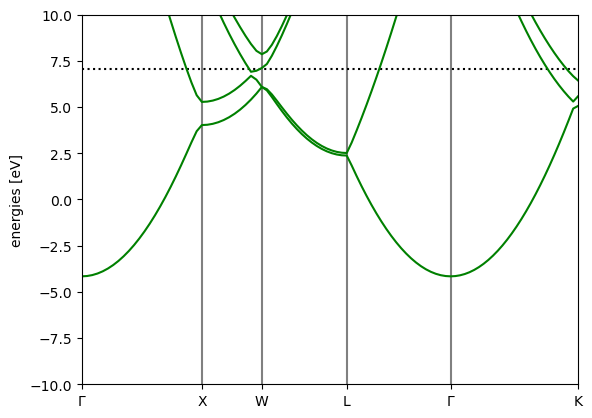

In [27]:
bs = calc.band_structure()
bs.plot(emax=10, filename='al-dft.png')